# Preprocesamiento y Ingeniería de Características
## Predicción del Resultado de Partidos de Fútbol (FTResult: H/D/A)

**Curso:** Minería de Datos (CC442) &nbsp;·&nbsp; **Fase 2 — Preprocesamiento**

**Miembros:** 

- Arbués Enrique Pérez Villegas
- Sergio Sebastian Pezo Jimenez
- Luis Andre Trujillo Serva

**Dataset:** *Club Football Match Data 2000–2025* (`adamgbor`, Kaggle).

---

Este cuaderno transforma los datos crudos en una matriz lista para el modelado. Continúa el análisis exploratorio (Fase 1): cada decisión de aquí se apoya en una propiedad medida allí. El preprocesamiento fija el techo de rendimiento de cualquier modelo posterior, así que ninguna manipulación se hace por costumbre; todas se justifican de forma matemática y quedan documentadas.

Cuatro compromisos ordenan el trabajo. Primero, la higiene anti-fuga: todo estadístico de transformación (medianas de imputación, media y desviación del escalado, categorías de la codificación) se calcula **solo sobre el conjunto de entrenamiento** y se aplica de forma ciega al resto, tal como exige la regla de oro contra el *data leakage*. Segundo, la ingeniería de características usa **únicamente información anterior a cada partido**. Tercero, la partición es **temporal**, nunca aleatoria, porque los datos tienen orden cronológico y una deriva real (efecto COVID). Cuarto, se descartan las cuotas de casas de apuestas: el modelo debe predecir sin esa "muleta del sabio", que es la versión honesta del problema.

## 0. Configuración del entorno

Se fija la semilla global (`random_state = 42`) y se cargan las dos tablas. La carga es robusta: busca una copia local del repositorio y, si no la encuentra, descarga el dataset público (portable a Google Colab con *Run All*).

In [1]:
import io
import json
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = Path("../figures")
if not FIG_DIR.exists():
    FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = Path("../data/processed")
if not OUT_DIR.parent.exists():
    OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Figuras ->", FIG_DIR.resolve())
print("Datos procesados ->", OUT_DIR.resolve())

Figuras -> /home/sergi/Documents/semesters/eight/dm/pc5/football-prediction/figures
Datos procesados -> /home/sergi/Documents/semesters/eight/dm/pc5/football-prediction/data/processed


In [2]:
def obtener_dataset() -> Path:
    for c in [Path("../data/raw"), Path("data/raw"),
              Path("pc5/football-prediction/data/raw")]:
        if (c / "Matches.csv").exists():
            return c
    try:
        import kagglehub
        p = Path(kagglehub.dataset_download("adamgbor/club-football-match-data-2000-2025"))
        if (p / "Matches.csv").exists():
            return p
    except Exception:
        pass
    destino = Path("data_futbol"); destino.mkdir(exist_ok=True)
    url = ("https://www.kaggle.com/api/v1/datasets/download/"
           "adamgbor/club-football-match-data-2000-2025")
    with urllib.request.urlopen(url, timeout=180) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(destino)
    return destino

RUTA = obtener_dataset()
matches = pd.read_csv(RUTA / "Matches.csv", low_memory=False, parse_dates=["MatchDate"])
elo = pd.read_csv(RUTA / "EloRatings.csv", parse_dates=["date"])
print("Matches:", matches.shape, " EloRatings:", elo.shape)

Matches: (230557, 48)  EloRatings: (245033, 4)


## 1. Contrato de columnas y limpieza base

**Fundamentación.** El eje del proyecto es separar la información disponible *antes* del partido de las estadísticas registradas *después*. Predecir con los goles del propio partido no tiene validez: es fuga de datos. El EDA cerró un contrato de columnas que aquí se aplica. Se descartan 35 columnas: las 15 estadísticas post-partido (tiros, faltas, tarjetas, medio tiempo), las 13 cuotas de mercado, los 6 cierres de casa de apuestas y `MatchTime` (57 % nulo). El marcador `FTHome`/`FTAway` es un caso especial: como *input* del partido en curso sería fuga, pero como materia prima para reconstruir el historial de partidos *anteriores* (goles recientes, enfrentamientos directos) es legítimo, así que se conserva de forma temporal. Las 3 filas sin etiqueta se eliminan. Todo se ordena cronológicamente: es la base de la ingeniería de características y de la partición.

In [3]:
TARGET = "FTResult"
TARGET_ORDER = ["H", "D", "A"]
CLASS_LABEL = {"H": "Local (H)", "D": "Empate (D)", "A": "Visita (A)"}

SAFE_PRE_NUMERIC = ["HomeElo", "AwayElo", "Form3Home", "Form5Home", "Form3Away", "Form5Away"]
GOALS_COLS = ["FTHome", "FTAway"]
CONTEXT_COLS = ["Division", "MatchDate", "HomeTeam", "AwayTeam"]
LEAKAGE_POST = ["HTHome", "HTAway", "HTResult", "HomeShots", "AwayShots",
                "HomeTarget", "AwayTarget", "HomeFouls", "AwayFouls",
                "HomeCorners", "AwayCorners", "HomeYellow", "AwayYellow",
                "HomeRed", "AwayRed"]
ODDS_COLS = ["OddHome", "OddDraw", "OddAway", "MaxHome", "MaxDraw", "MaxAway",
             "Over25", "Under25", "MaxOver25", "MaxUnder25",
             "HandiSize", "HandiHome", "HandiAway"]
CLOSING_COLS = ["C_LTH", "C_LTA", "C_VHD", "C_VAD", "C_HTB", "C_PHB"]

n0 = len(matches)
n_sin_target = int(matches[TARGET].isna().sum())
df = matches[matches[TARGET].notna()].copy()

keep = CONTEXT_COLS + SAFE_PRE_NUMERIC + GOALS_COLS + [TARGET]
df = df[keep].copy()
df = df.sort_values(["MatchDate", "Division", "HomeTeam"], kind="mergesort").reset_index(drop=True)
df.insert(0, "match_id", df.index.astype("int64"))

print(f"Filas crudas: {n0:,}  ->  sin FTResult descartadas: {n_sin_target}  ->  quedan {len(df):,}")
print(f"Columnas conservadas ({len(keep)}): {keep}")
print(f"Descartadas: {len(LEAKAGE_POST)} fuga + {len(ODDS_COLS)} cuotas + {len(CLOSING_COLS)} cierres + 1 MatchTime")
print(f"Rango temporal: {df['MatchDate'].min().date()} -> {df['MatchDate'].max().date()}")

Filas crudas: 230,557  ->  sin FTResult descartadas: 3  ->  quedan 230,554
Columnas conservadas (13): ['Division', 'MatchDate', 'HomeTeam', 'AwayTeam', 'HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome', 'FTAway', 'FTResult']
Descartadas: 15 fuga + 13 cuotas + 6 cierres + 1 MatchTime
Rango temporal: 2000-07-28 -> 2025-06-01


### Interpretación

El dataset queda en 230 554 partidos con 13 columnas de trabajo más el identificador. Solo dos grupos traen nulos relevantes: el Elo (~38.6 %) y las formas (~0.65 %). El resto de la limpieza es un descarte por contrato, no una imputación: las columnas eliminadas no aportan información *predictiva válida*, por eso se van sin discusión. El orden cronológico es la pieza que habilita todo lo que sigue.

## 2. Recuperación de Elo por *join* temporal

**Fundamentación.** El Elo falta en el 38.6 % de las filas, pero el nulo no es aleatorio: es estructural por liga (el EDA mostró que ligas menores no tienen cobertura). Antes de imputar conviene recuperar el Elo *real* que sí existe en la tabla `EloRatings`. La recuperación respeta el orden temporal con un `merge_asof` "hacia atrás": para cada partido se toma el último rating del club con fecha $\le$ la del partido. Formalmente, para un club $c$ y una fecha de partido $t$,

$$ \widehat{\text{Elo}}(c,t) = \text{Elo}(c,\tau^*), \qquad \tau^* = \max\{\tau : \tau \le t\}. $$

Esto no es fuga: usa solo información anterior al partido. Solo se rellenan los nulos; los valores de Elo ya presentes se respetan. La armonización de nombres corrige discrepancias triviales (espacios sobrantes) y un puñado de alias frecuentes.

In [4]:
import re
CLUB_ALIASES = {
    "Paris SG": "Paris Saint-Germain", "Man United": "Manchester United",
    "Man City": "Manchester City", "Ath Madrid": "Atletico Madrid",
    "Ath Bilbao": "Athletic Bilbao", "Sociedad": "Real Sociedad",
    "Betis": "Real Betis", "Sp Lisbon": "Sporting CP",
    "Nott'm Forest": "Nottingham Forest", "Inter": "Internazionale",
}
def norm_club(s):
    if not isinstance(s, str): return ""
    return re.sub(r"\s+", " ", s).strip()
def norm_side(serie):
    return serie.map(lambda x: CLUB_ALIASES.get(x, x)).map(norm_club)

elo["club_norm"] = norm_side(elo["club"])
elo_h = elo[["club_norm", "date", "elo"]].dropna(subset=["club_norm"])
df["home_norm"] = norm_side(df["HomeTeam"])
df["away_norm"] = norm_side(df["AwayTeam"])

def asof_elo(club_col):
    left = (df[["match_id", "MatchDate", club_col]]
            .rename(columns={club_col: "club_norm"})
            .sort_values("MatchDate", kind="mergesort"))
    right = elo_h.sort_values("date", kind="mergesort")
    m = pd.merge_asof(left, right, left_on="MatchDate", right_on="date",
                      by="club_norm", direction="backward")
    return m.set_index("match_id")["elo"].reindex(df["match_id"]).to_numpy()

home_na0, away_na0 = int(df.HomeElo.isna().sum()), int(df.AwayElo.isna().sum())
df["HomeElo"] = df["HomeElo"].fillna(pd.Series(asof_elo("home_norm"), index=df.index))
df["AwayElo"] = df["AwayElo"].fillna(pd.Series(asof_elo("away_norm"), index=df.index))
home_na1, away_na1 = int(df.HomeElo.isna().sum()), int(df.AwayElo.isna().sum())

elo_clubs = set(elo_h["club_norm"])
rem = df[df["HomeElo"].isna()]
absent = int((~rem["home_norm"].isin(elo_clubs)).sum())
print(f"Nulo HomeElo: {home_na0:,} ({100*home_na0/len(df):.1f}%) -> {home_na1:,} ({100*home_na1/len(df):.1f}%)")
print(f"Elo real recuperado por join: Home {home_na0-home_na1:,} | Away {away_na0-away_na1:,}")
print(f"De los {home_na1:,} nulos restantes, {absent:,} ({100*absent/max(home_na1,1):.0f}%) son equipos AUSENTES de EloRatings")
byd = df.groupby("Division")["HomeElo"].apply(lambda s: 100*s.isna().mean()).sort_values(ascending=False)
print("\nNulo residual por liga (top 8):")
print(byd.head(8).round(1).to_string())
df = df.drop(columns=["home_norm", "away_norm"])

Nulo HomeElo: 88,959 (38.6%) -> 78,336 (34.0%)
Elo real recuperado por join: Home 10,623 | Away 10,659
De los 78,336 nulos restantes, 73,623 (94%) son equipos AUSENTES de EloRatings

Nulo residual por liga (top 8):
Division
ARG    100.0
BRA    100.0
CHN    100.0
JAP    100.0
IRL    100.0
MEX    100.0
USA    100.0
SUI    100.0


### Interpretación

El *join* recupera unos 10 600 partidos con Elo real, pero el grueso del nulo permanece: cerca del 94 % de lo que queda son equipos que sencillamente no están en `EloRatings`, porque esa tabla solo cubre 19 países europeos. Ligas como Argentina, Brasil, China, Japón, Estados Unidos o México aparecen con 100 % de Elo faltante. La lectura es clara: el nulo del Elo es una **propiedad estructural por liga**, no un dato perdido al azar. Esto condiciona la imputación posterior (la mediana de la liga es la referencia natural) y justifica marcar cada fila con una bandera `elo_missing`, para que el modelo distinga "no hay señal de Elo aquí" de un valor real.

## 3. Ingeniería de características (solo con el pasado)

**Fundamentación.** Todas las variables derivadas se calculan usando exclusivamente partidos anteriores a cada fila. Es la garantía anti-fuga a nivel de instancia: ninguna ventana móvil incluye el partido en curso (se aplica un desplazamiento de una posición antes de agregar) y el head-to-head recorre el calendario de forma incremental. Se construyen medias móviles de goles a favor y en contra de los últimos 5 partidos de cada equipo, días de descanso, rachas de victorias, el historial directo entre los dos rivales y una bandera de liga top-5. La ventana 5 coincide con la variable `Form5` del dataset y con la práctica de la literatura.

In [5]:
ROLL_WINDOW = 5
TOP5 = {"E0", "SP1", "I1", "D1", "F1"}

def win_streak_into(won_bool):
    won = won_bool.astype(int).to_numpy(); out = np.zeros(len(won)); run = 0
    for i in range(len(won)):
        out[i] = run
        run = run + 1 if won[i] == 1 else 0
    return pd.Series(out, index=won_bool.index)

home = pd.DataFrame({"match_id": df.match_id, "team": df.HomeTeam, "venue": "H",
                     "date": df.MatchDate, "gf": df.FTHome, "ga": df.FTAway,
                     "won": df.FTResult.eq("H")})
away = pd.DataFrame({"match_id": df.match_id, "team": df.AwayTeam, "venue": "A",
                     "date": df.MatchDate, "gf": df.FTAway, "ga": df.FTHome,
                     "won": df.FTResult.eq("A")})
lg = pd.concat([home, away], ignore_index=True).sort_values(["team", "match_id"], kind="mergesort")
g = lg.groupby("team", sort=False)
w = ROLL_WINDOW
lg["gf5"] = g["gf"].transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
lg["ga5"] = g["ga"].transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
lg["rest_days"] = g["date"].transform(lambda s: s.diff().dt.days)
lg["win_streak"] = g["won"].transform(win_streak_into)
piv = lg.pivot_table(index="match_id", columns="venue",
                     values=["gf5", "ga5", "rest_days", "win_streak"])
piv.columns = [f"{'home' if v=='H' else 'away'}_{st}" for st, v in piv.columns]
df = df.merge(piv, on="match_id", how="left")

played = np.zeros(len(df)); winrate = np.full(len(df), np.nan); avg_goals = np.full(len(df), np.nan)
hist = {}
for i, (h, a, fh, fa, res) in enumerate(
        df[["HomeTeam", "AwayTeam", "FTHome", "FTAway", "FTResult"]].itertuples(index=False)):
    key = frozenset((h, a)); prev = hist.get(key)
    if prev:
        played[i] = len(prev)
        avg_goals[i] = sum(tg for _, tg in prev) / len(prev)
        winrate[i] = sum(1 for wn, _ in prev if wn == h) / len(prev)
    winner = h if res == "H" else (a if res == "A" else None)
    hist.setdefault(key, []).append((winner, int(fh + fa)))
df["h2h_played"] = played
df["h2h_home_winrate"] = winrate
df["h2h_avg_goals"] = avg_goals
df["is_top_league"] = df["Division"].isin(TOP5).astype(int)

df = df.drop(columns=GOALS_COLS)  # el marcador ya cumplio su rol historico
nuevos = ["home_gf5","away_gf5","home_ga5","away_ga5","home_rest_days","away_rest_days",
          "home_win_streak","away_win_streak","h2h_played","h2h_home_winrate",
          "h2h_avg_goals","is_top_league"]
print(f"Features construidas ({len(nuevos)}): {nuevos}")
print(df[nuevos].isna().mean().mul(100).round(2).to_string())

Features construidas (12): ['home_gf5', 'away_gf5', 'home_ga5', 'away_ga5', 'home_rest_days', 'away_rest_days', 'home_win_streak', 'away_win_streak', 'h2h_played', 'h2h_home_winrate', 'h2h_avg_goals', 'is_top_league']
home_gf5            0.27
away_gf5            0.26
home_ga5            0.27
away_ga5            0.26
home_rest_days      0.27
away_rest_days      0.26
home_win_streak     0.00
away_win_streak     0.00
h2h_played          0.00
h2h_home_winrate    9.72
h2h_avg_goals       9.72
is_top_league       0.00


### Interpretación

Las medias móviles rondan 1.3 goles, en línea con el promedio del dataset, y los días de descanso caen alrededor de 11–12, coherente con un calendario semanal con pausas. Los nulos son mínimos y tienen explicación: aparecen en el primer partido de cada equipo (sin historial) y en los primeros enfrentamientos entre dos rivales (sin head-to-head previo). No son datos corruptos, son la ausencia natural de pasado; se imputan más adelante con un criterio de dominio. El marcador se elimina en este punto: ya entregó toda su información como historial y mantenerlo sería fuga.

## 4. Partición temporal

**Fundamentación.** La rúbrica prohíbe el K-Fold aleatorio en series temporales: entrenar con el futuro para predecir el pasado invalida el poder predictivo. La razón teórica es la cota de generalización: la desigualdad de Hoeffding y la cota VC exigen que la hipótesis se fije *antes* de tocar el conjunto de evaluación,

$$P\big[\,|E_{in}(g)-E_{out}(g)|>\epsilon\,\big]\le 4\,m_{\mathcal H}(2N)\,e^{-\frac{1}{8}\epsilon^2 N}.$$

Un pliegue aleatorio rompe ese supuesto. Se usa un *holdout* por fecha: entrenamiento hasta 2021, validación 2022–2023 y prueba 2024–2025. La frontera es limpia: ninguna fila de entrenamiento es posterior a una de validación o prueba.

In [6]:
df["year"] = df["MatchDate"].dt.year
def asignar(y):
    if y <= 2021: return "train"
    if 2022 <= y <= 2023: return "val"
    return "test"
df["split"] = df["year"].map(asignar)

print("Tamaño y rango por split:")
for name in ("train", "val", "test"):
    sub = df[df.split == name]
    print(f"  {name:<6} {len(sub):>8,} ({100*len(sub)/len(df):4.1f}%)  "
          f"[{sub.MatchDate.min().date()} -> {sub.MatchDate.max().date()}]")
tmax = df.loc[df.split=='train','MatchDate'].max()
vmin = df.loc[df.split=='val','MatchDate'].min()
vmax = df.loc[df.split=='val','MatchDate'].max()
temin = df.loc[df.split=='test','MatchDate'].min()
print(f"\nFrontera temporal limpia (train<val<test): {tmax<vmin and vmax<temin}")
print("\nBalance de clases por split (%):")
print(f"  {'split':<6} " + " ".join(f"{c:>7}" for c in TARGET_ORDER))
for name in ("train","val","test"):
    p = df[df.split==name][TARGET].value_counts(normalize=True)*100
    print(f"  {name:<6} " + " ".join(f"{p.get(c,0):7.2f}" for c in TARGET_ORDER))

Tamaño y rango por split:
  train   191,099 (82.9%)  [2000-07-28 -> 2021-12-31]
  val      24,669 (10.7%)  [2022-01-01 -> 2023-12-31]
  test     14,786 ( 6.4%)  [2024-01-01 -> 2025-06-01]

Frontera temporal limpia (train<val<test): True

Balance de clases por split (%):
  split        H       D       A
  train    44.81   26.57   28.63
  val      43.89   26.16   29.95
  test     43.43   26.37   30.20


### Interpretación

El reparto queda en torno a 83/11/6 %. El entrenamiento es amplio porque la densidad de partidos crece con los años, y la prueba corresponde al último año y medio: es el escenario honesto de despliegue, predecir el futuro con el pasado. El balance de clases se mantiene estable con una leve deriva (la victoria local baja de 44.8 % a 43.4 %), justamente el desplazamiento que la partición temporal preserva y que un reparto aleatorio borraría al mezclar épocas.

## 5. Imputación con disciplina *train-only* y diferencias local–visita

**Fundamentación.** Aquí se cumple la regla de oro: toda mediana de imputación se calcula solo con el entrenamiento y se aplica ciega al resto. La elección del estadístico no es arbitraria. Imputar con la media colapsa la varianza —si $m$ de $n+m$ valores se reemplazan por la media, la varianza observada se contrae en un factor $n/(n+m)$— y arrastra los ejes de la covarianza, degradando a modelos de distancia y a PCA. La mediana (minimizador $L_1$) es robusta y no crea ese pico artificial. Por dominio: el Elo se imputa con la mediana de su **liga** (con respaldo global) porque el nulo es estructural por liga, y se acompaña de la bandera `elo_missing`; la forma se imputa con 0 (sin historial, cero puntos acumulados); las medias móviles y el descanso con la mediana de train; el head-to-head sin precedentes recibe una tasa neutral de 0.5. Después se añaden las diferencias local–visita, que el EDA identificó como la señal más informativa.

In [7]:
df["elo_missing"] = (df.HomeElo.isna() | df.AwayElo.isna()).astype(int)
tr = df.split == "train"

elo_long = pd.concat([
    df.loc[tr, ["Division", "HomeElo"]].rename(columns={"HomeElo": "e"}),
    df.loc[tr, ["Division", "AwayElo"]].rename(columns={"AwayElo": "e"})])
league_med = elo_long.groupby("Division")["e"].median()
global_med = float(elo_long["e"].median())
for col in ("HomeElo", "AwayElo"):
    df[col] = df[col].fillna(df["Division"].map(league_med)).fillna(global_med)

for col in ["Form3Home", "Form5Home", "Form3Away", "Form5Away"]:
    df[col] = df[col].fillna(0.0)
for col in ["home_gf5","away_gf5","home_ga5","away_ga5","home_rest_days","away_rest_days"]:
    df[col] = df[col].fillna(float(df.loc[tr, col].median()))
df["h2h_home_winrate"] = df["h2h_home_winrate"].fillna(0.5)
df["h2h_avg_goals"] = df["h2h_avg_goals"].fillna(float(df.loc[tr, "h2h_avg_goals"].median()))

df["elo_diff"]   = df.HomeElo - df.AwayElo
df["form5_diff"] = df.Form5Home - df.Form5Away
df["form3_diff"] = df.Form3Home - df.Form3Away
df["gf5_diff"]   = df.home_gf5 - df.away_gf5
df["ga5_diff"]   = df.home_ga5 - df.away_ga5

print(f"Elo: mediana global train = {global_med:.1f} | ligas con mediana propia = {int(league_med.notna().sum())}")
print(f"Filas con elo_missing=1: {int(df.elo_missing.sum()):,} ({100*df.elo_missing.mean():.1f}%)")
print("Nulos restantes en features numéricas:", int(df.filter(regex='elo_diff|form|_gf5|_ga5|rest|streak|h2h|Elo').isna().sum().sum()))

Elo: mediana global train = 1504.9 | ligas con mediana propia = 30
Filas con elo_missing=1: 92,951 (40.3%)
Nulos restantes en features numéricas: 0


### Interpretación

La mediana global de train ronda los 1505 puntos de Elo. Treinta ligas tienen mediana propia; las ocho que carecen por completo de Elo (las no europeas) caen al valor global, lo que hace que su `elo_diff` sea 0 y que la bandera `elo_missing` cargue toda la señal de "aquí no hay rating". Es un tratamiento honesto: en esas ligas el modelo se apoyará en la forma y las medias móviles, no en un Elo inventado. Tras la imputación no quedan nulos, y las diferencias local–visita ya están listas como variables de máxima señal.

## 6. Escalado y codificación con `ColumnTransformer`

**Fundamentación.** Los algoritmos de distancia y de gradiente necesitan variables en escala comparable; si una domina en magnitud, anula a las demás y deforma la optimización. La estandarización *z-score* lleva cada variable a media 0 y varianza 1,

$$x'_{ij} = \frac{x_{ij}-\mu_j}{\sigma_j},$$

con $\mu_j$ y $\sigma_j$ calculadas **solo sobre el entrenamiento**. La liga (`Division`) se codifica con *one-hot*; las banderas binarias pasan sin tocar. Todo se encapsula en un `ColumnTransformer` que se ajusta una vez sobre train y transforma de forma idéntica a validación y prueba, cerrando cualquier vía de fuga.

In [8]:
CONTINUOUS = (["HomeElo","AwayElo","elo_diff","Form5Home","Form5Away","form5_diff",
               "Form3Home","Form3Away","form3_diff","home_gf5","away_gf5","gf5_diff",
               "home_ga5","away_ga5","ga5_diff","home_rest_days","away_rest_days",
               "home_win_streak","away_win_streak","h2h_played","h2h_home_winrate","h2h_avg_goals"])
FLAGS = ["is_top_league", "elo_missing"]
CATEGORICAL = ["Division"]

pre = ColumnTransformer([
    ("num", StandardScaler(), CONTINUOUS),
    ("flags", "passthrough", FLAGS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
], remainder="drop")

Xtr_raw = df[df.split == "train"]
pre.fit(Xtr_raw)
feat_names = list(pre.get_feature_names_out())

datos = {}
print("Shapes por split:")
for name in ("train", "val", "test"):
    sub = df[df.split == name]
    X = pd.DataFrame(pre.transform(sub), columns=feat_names).reset_index(drop=True)
    y = sub[TARGET].reset_index(drop=True)
    datos[name] = (X, y)
    print(f"  {name:<6} X={X.shape}  H/D/A = "
          f"{(y=='H').mean():.3f}/{(y=='D').mean():.3f}/{(y=='A').mean():.3f}")
print(f"\nFeatures de salida: {len(feat_names)} "
      f"({len(CONTINUOUS)} continuas + {len(FLAGS)} flags + one-hot Division)")

Shapes por split:


  train  X=(191099, 62)  H/D/A = 0.448/0.266/0.286
  val    X=(24669, 62)  H/D/A = 0.439/0.262/0.300
  test   X=(14786, 62)  H/D/A = 0.434/0.264/0.302

Features de salida: 62 (22 continuas + 2 flags + one-hot Division)


### Interpretación

La matriz final tiene 62 columnas: 22 continuas estandarizadas, 2 banderas y 38 indicadores de liga. El ajuste ocurrió solo con el entrenamiento, de modo que las medias y desviaciones que estandarizan validación y prueba provienen del pasado, nunca del futuro. Conservar los nombres de las columnas no es cosmético: es lo que permitirá interpretar el modelo con SHAP en la fase de evaluación.

## 7. Reducción de dimensionalidad con PCA

**Fundamentación.** El EDA detectó multicolinealidad: las diferencias son combinaciones lineales exactas de sus componentes (`elo_diff = HomeElo − AwayElo`, etc.), lo que vuelve singular a la matriz y dispara el VIF. PCA es la herramienta natural para diagnosticarlo y absorberlo. Sobre datos centrados, diagonaliza la matriz de covarianza $\Sigma = \frac{1}{n-1}X^\top X = S\Lambda S^\top$ y proyecta $Y = S^\top X$, dejando la covarianza de las proyecciones diagonal (componentes descorrelacionados). Los autovalores $\lambda_j = \sigma_j^2$ ordenan la varianza. Se elige el número de componentes por dos criterios exigidos por la rúbrica: retener el 95 % de la varianza acumulada y el criterio del codo.

Componentes: 22 | k para 95% varianza: 13 | autovalores ~0: 5


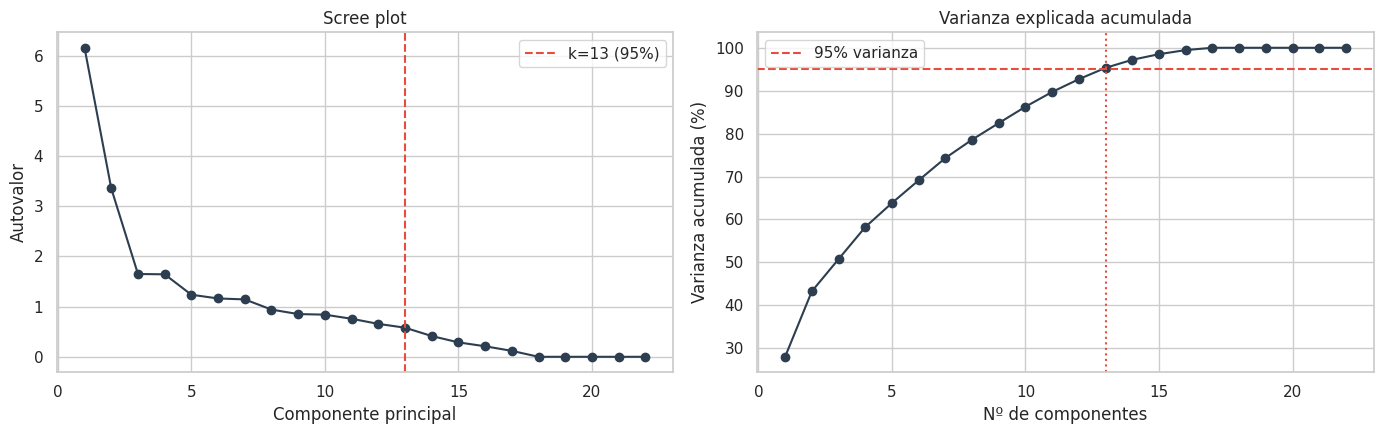

Variante PCA: {'train': (191099, 53), 'val': (24669, 53), 'test': (14786, 53)}


In [9]:
num_cols = [c for c in feat_names if c.startswith("num__")]
other_cols = [c for c in feat_names if not c.startswith("num__")]
Xtr = datos["train"][0]

pca_full = PCA(random_state=RANDOM_STATE).fit(Xtr[num_cols].to_numpy())
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
eig = pca_full.explained_variance_
k95 = int(np.argmax(cum >= 0.95) + 1)
n_zero = int((eig < 1e-8).sum())
print(f"Componentes: {len(evr)} | k para 95% varianza: {k95} | autovalores ~0: {n_zero}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(range(1, len(eig)+1), eig, "o-", color="#2c3e50")
ax[0].axvline(k95, ls="--", color="#e74c3c", label=f"k={k95} (95%)")
ax[0].set(xlabel="Componente principal", ylabel="Autovalor", title="Scree plot")
ax[0].legend()
ax[1].plot(range(1, len(cum)+1), 100*cum, "o-", color="#2c3e50")
ax[1].axhline(95, ls="--", color="#e74c3c", label="95% varianza")
ax[1].axvline(k95, ls=":", color="#e74c3c")
ax[1].set(xlabel="Nº de componentes", ylabel="Varianza acumulada (%)", title="Varianza explicada acumulada")
ax[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"pca_scree.png", dpi=150); plt.show()

pca_k = PCA(n_components=k95, random_state=RANDOM_STATE).fit(Xtr[num_cols].to_numpy())
pc_names = [f"PC{i+1}" for i in range(k95)]
datos_pca = {}
for name in ("train", "val", "test"):
    X = datos[name][0]
    Z = pca_k.transform(X[num_cols].to_numpy())
    datos_pca[name] = pd.concat([pd.DataFrame(Z, columns=pc_names),
                                 X[other_cols].reset_index(drop=True)], axis=1)
print("Variante PCA:", {k: v.shape for k, v in datos_pca.items()})

### Interpretación

PCA confirma lo que el EDA anticipó: aparecen exactamente cinco autovalores nulos, uno por cada diferencia redundante. Las 22 variables continuas viven en realidad en un espacio de 17 dimensiones efectivas, y el 95 % de la varianza se alcanza con 13 componentes. Esta variante reducida sirve a los modelos lineales y de distancia, que sufren la colinealidad; los árboles y ensembles, inmunes a ella, seguirán usando la matriz original con nombres. No hay maldición de la dimensionalidad grave aquí —el problema no era el tamaño, sino la redundancia— y PCA la disuelve de raíz.

## 8. Verificación anti-fuga

**Fundamentación.** Un preprocesamiento fugado se delata con una exactitud sospechosamente alta. La literatura sitúa el techo de la predicción pre-partido en tres clases alrededor de 52–57 %, y buena parte de ese margen lo aportan las cuotas, que aquí se descartaron. Un clasificador lineal sencillo sirve de sonda: si su exactitud fuera superior a ~65 % habría que sospechar fuga. También sirve para fijar el piso realista y para exhibir por qué la métrica correcta es el F1 macro y no la exactitud.

In [10]:
Xtr, ytr = datos["train"]; Xva, yva = datos["val"]
dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
logr = LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0,
                          random_state=RANDOM_STATE).fit(Xtr, ytr)
for nombre, m in [("Dummy (mayoritaria)", dummy), ("LogReg balanced", logr)]:
    p = m.predict(Xva)
    print(f"{nombre:<22} acc={accuracy_score(yva,p):.4f}  f1_macro={f1_score(yva,p,average='macro'):.4f}")
print()
print(classification_report(yva, logr.predict(Xva), digits=3,
                            target_names=[CLASS_LABEL[c] for c in sorted(set(yva))]))

Dummy (mayoritaria)    acc=0.4389  f1_macro=0.2033
LogReg balanced        acc=0.4482  f1_macro=0.4203



              precision    recall  f1-score   support

  Visita (A)      0.402     0.568     0.471      7389
  Empate (D)      0.306     0.222     0.257      6453
   Local (H)      0.569     0.501     0.533     10827

    accuracy                          0.448     24669
   macro avg      0.426     0.430     0.420     24669
weighted avg      0.450     0.448     0.442     24669



### Interpretación

La sonda da exactitud ~0.45 y F1 macro ~0.42, sin rastro de fuga: nada de valores por encima de 0.65. El detalle es revelador. En exactitud, la regresión apenas supera al clasificador trivial que siempre dice "local" (0.439 → 0.448), pero en F1 macro lo duplica (0.20 → 0.42). La diferencia está en el empate: con `class_weight` el modelo recupera algo de recall para la clase D, que de otro modo desaparecería. Esta es la prueba empírica de por qué el modelado optimizará F1 macro y reportará la métrica por clase, no la exactitud global. El empate, con recall en torno a 0.22, confirma su techo estructural bajo, tal como mostró el análisis de la clase difusa.

## 9. Persistencia de los datos procesados

Se guardan las matrices en formato *parquet*, que conserva los nombres de las columnas (necesario para la interpretación con SHAP en la evaluación) y los tipos. Se persisten la matriz cruda estandarizada y la variante PCA, junto con el transformador ajustado y la lista de características, para que la fase de modelado los cargue sin recomputar.

In [11]:
for name in ("train", "val", "test"):
    X, y = datos[name]
    X.to_parquet(OUT_DIR / f"X_{name}.parquet", index=False)
    y.to_frame(TARGET).to_parquet(OUT_DIR / f"y_{name}.parquet", index=False)
    datos_pca[name].to_parquet(OUT_DIR / f"X_{name}_pca.parquet", index=False)

df[["match_id", "MatchDate", "Division", "split"]].to_parquet(OUT_DIR / "index_ref.parquet", index=False)
(OUT_DIR / "feature_names.json").write_text(json.dumps(feat_names, indent=2), encoding="utf-8")
try:
    MODELS_DIR = Path("../models"); MODELS_DIR.mkdir(exist_ok=True)
    joblib.dump(pre, MODELS_DIR / "preprocessor.joblib")
except Exception as e:
    print("aviso modelos:", e)
print("Guardado en", OUT_DIR.resolve())
print(sorted(p.name for p in OUT_DIR.glob("*.parquet")))

Guardado en /home/sergi/Documents/semesters/eight/dm/pc5/football-prediction/data/processed
['X_test.parquet', 'X_test_pca.parquet', 'X_train.parquet', 'X_train_pca.parquet', 'X_val.parquet', 'X_val_pca.parquet', '_matches_clean.parquet', '_matches_elo.parquet', '_matches_features.parquet', '_matches_split.parquet', 'index_ref.parquet', 'y_test.parquet', 'y_train.parquet', 'y_val.parquet']


## 10. Conclusiones y puente al modelado

El preprocesamiento entrega una matriz de 62 características construida bajo tres garantías verificables: sin fuga temporal (features solo con el pasado, partición cronológica), sin fuga estadística (todo ajuste calculado solo en train) y sin la muleta de las cuotas. Los hallazgos del EDA se confirman de forma cuantitativa: la multicolinealidad se materializa en cinco autovalores nulos, el nulo del Elo resulta estructural por liga y se trata con imputación por liga más una bandera, y el empate se revela como la clase difícil ya desde una sonda lineal.

Tres decisiones quedan fijadas para la Fase 3. La validación será temporal, con `TimeSeriesSplit` como esquema interno para elegir hiperparámetros. La métrica de optimización será el F1 macro, con reporte por clase, Cohen's Kappa y ROC-AUC. Y el desbalance moderado se atacará con `class_weight` de base, dejando SMOTE (solo en entrenamiento) como experimento controlado para el empate. Los modelos vistos en clase —árbol de decisión, SVM, Random Forest y *boosting*, con PCA como reducción— forman la base obligatoria; sobre ella se añaden los *gradient boosting* modernos y los ensambles por votación y apilamiento, que constituyen la contribución del trabajo.